Dataset Shape: (891, 12)

Column Names:
['passengerid', 'survived', 'pclass', 'name', 'sex', 'age', 'sibsp', 'parch', 'ticket', 'fare', 'cabin', 'embarked']

First 5 rows:


,passengerid,survived,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S



Numerical Columns:
['passengerid', 'survived', 'pclass', 'age', 'sibsp', 'parch', 'fare']


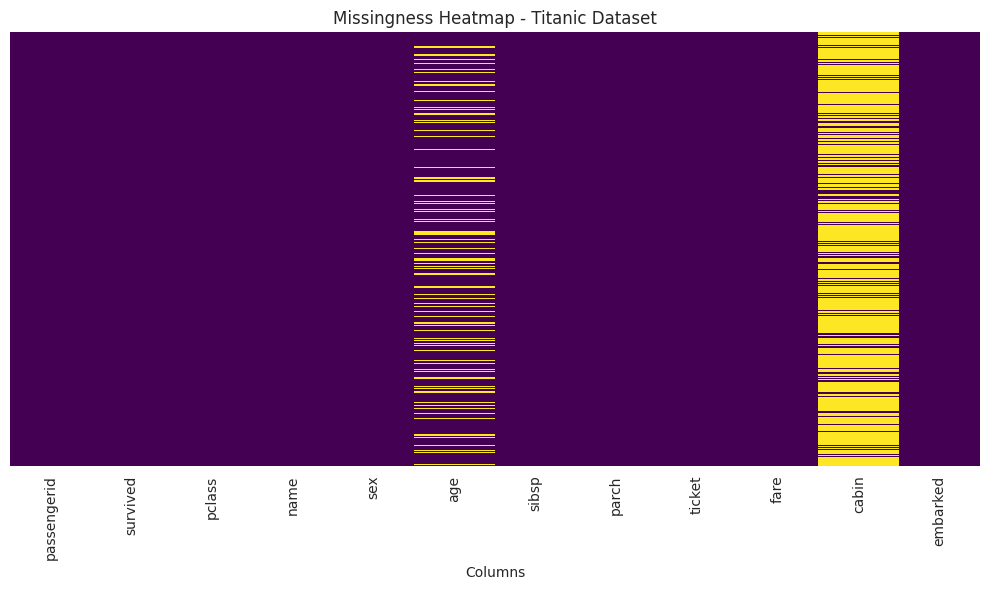

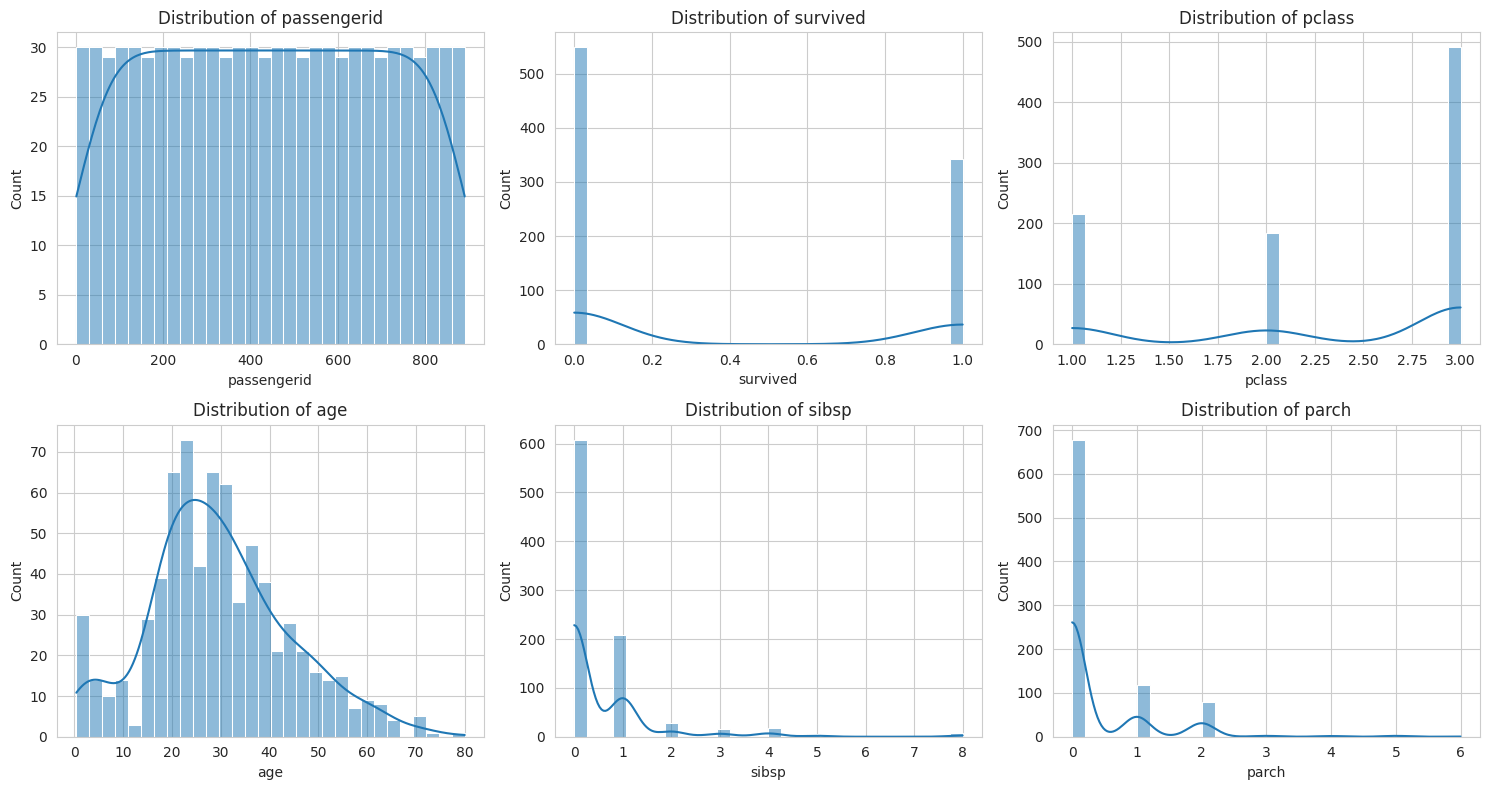

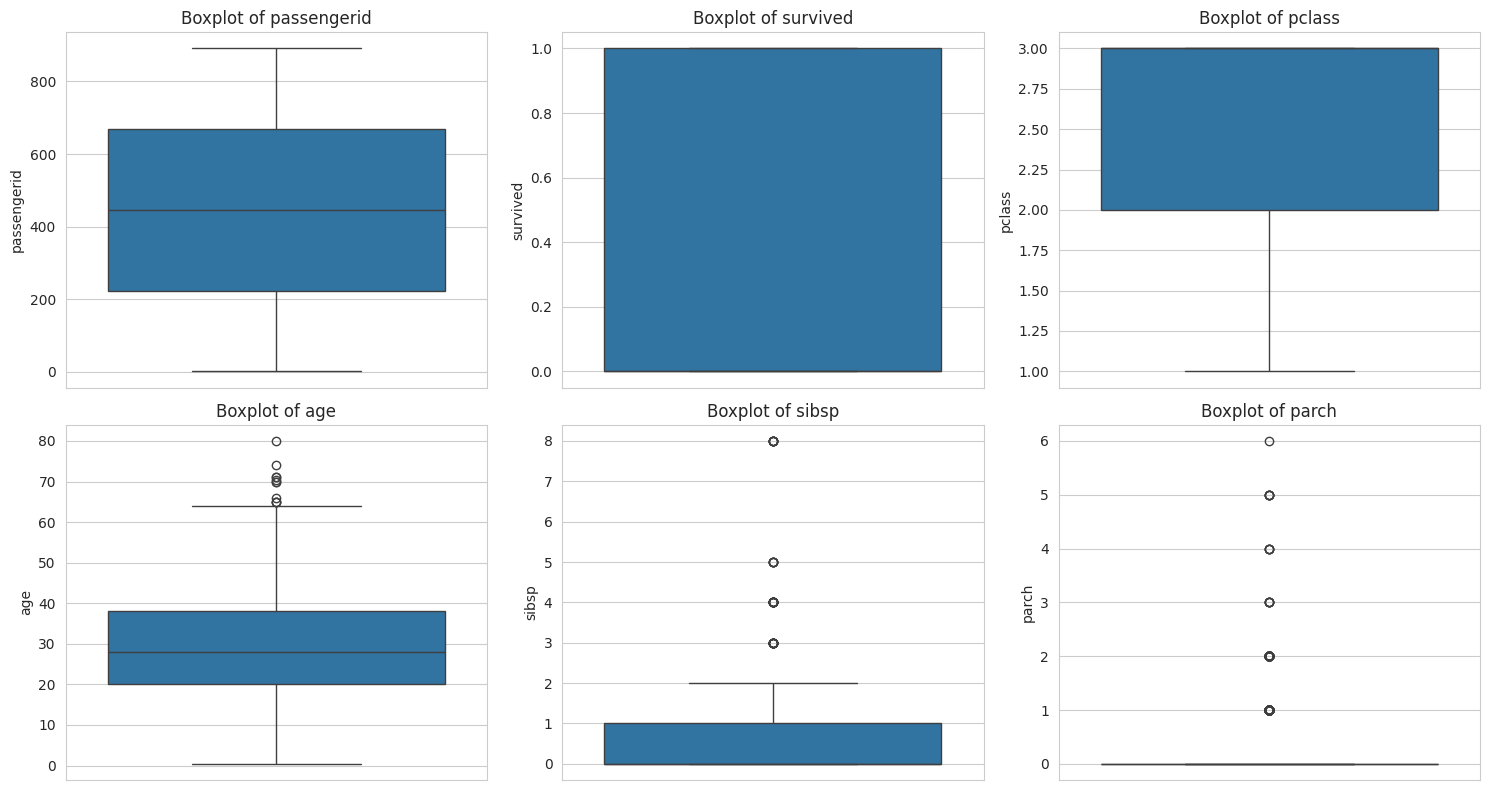

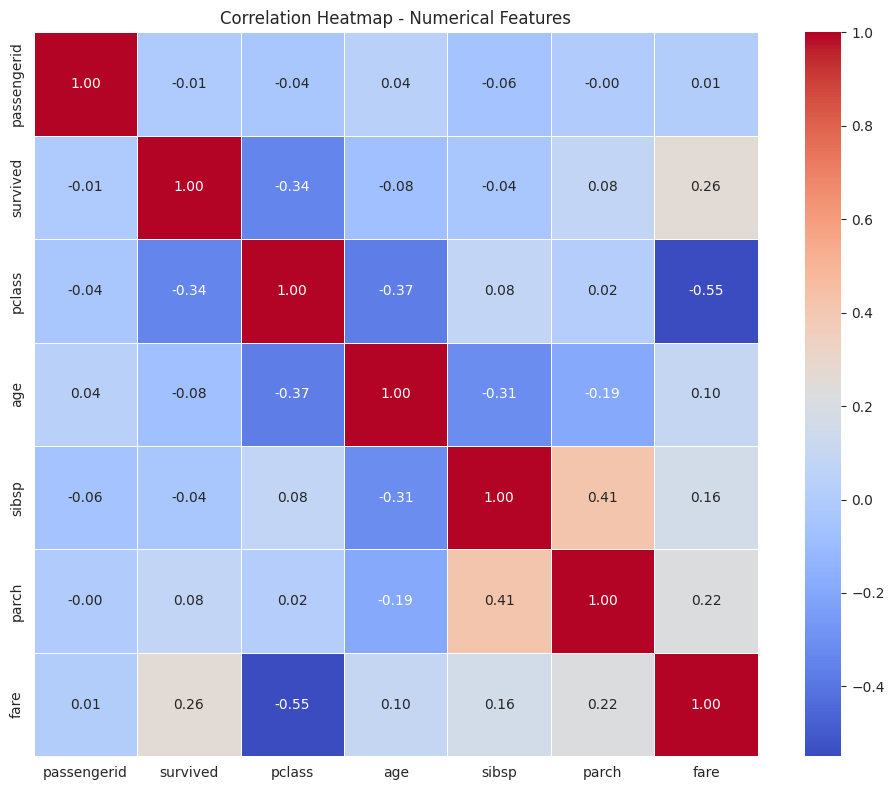

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.backends.backend_pdf import PdfPages

sns.set_style("whitegrid")

# Load Titanic dataset
df = pd.read_csv('https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv')

# Standardize column names
df.columns = df.columns.str.lower().str.replace(' ', '_')

# Display dataset
print("Dataset Shape:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

# Select numerical columns automatically
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

print("\nNumerical Columns:")
print(num_cols)


# ---------------------------------------------------
# 1. MISSINGNESS HEATMAP
# ---------------------------------------------------

fig1 = plt.figure(figsize=(10, 6))

sns.heatmap(
    df.isnull(),
    cbar=False,
    cmap="viridis",
    yticklabels=False
)

plt.title("Missingness Heatmap - Titanic Dataset")
plt.xlabel("Columns")
plt.tight_layout()
plt.show()


# ---------------------------------------------------
# 2. HISTOGRAMS
# ---------------------------------------------------

fig2, axes = plt.subplots(2, 3, figsize=(15, 8))

for i, col in enumerate(num_cols):
    if i >= 6:
        break

    row, colpos = divmod(i, 3)

    sns.histplot(
        df[col].dropna(),
        bins=30,
        kde=True,
        ax=axes[row, colpos]
    )

    axes[row, colpos].set_title(f'Distribution of {col}')

plt.tight_layout()
plt.show()


# ---------------------------------------------------
# 3. BOXPLOTS
# ---------------------------------------------------

fig3, axes3 = plt.subplots(2, 3, figsize=(15, 8))

for i, col in enumerate(num_cols):
    if i >= 6:
        break

    row, colpos = divmod(i, 3)

    sns.boxplot(
        y=df[col],
        ax=axes3[row, colpos]
    )

    axes3[row, colpos].set_title(f'Boxplot of {col}')

plt.tight_layout()
plt.show()


# ---------------------------------------------------
# 4. CORRELATION HEATMAP
# ---------------------------------------------------

fig4 = plt.figure(figsize=(10, 8))

numeric_df = df.select_dtypes(include=['int64', 'float64'])

corr_matrix = numeric_df.corr()

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    square=True,
    linewidths=0.5
)

plt.title('Correlation Heatmap - Numerical Features')
plt.tight_layout()
plt.show()


# ---------------------------------------------------
# 5. CREATE PDF REPORT
# ---------------------------------------------------

with PdfPages('EDA_Report_Titanic.pdf') as pdf:

    pdf.savefig(fig1)
    pdf.savefig(fig2)
    pdf.savefig(fig3)
    pdf.savefig(fig4)


# ---------------------------------------------------
# 6. DOWNLOAD PDF
# ---------------------------------------------------

from google.colab import files

files.download('EDA_Report_Titanic.pdf')